### Model inspired by:

- [1] Offshore Pipelaying Dynamics. Gullik Anthon Jensen
- [2] A nonlinear PDE formulation for offshore vessel pipeline installation. Gullik A. Jensen et al
- [3] Modeling and Control of Offshore Pipelay Operations Based on a Finite Strain Pipe Model. Gullik A. Jensen

### Implementation aspects:

- The model can be applied to normal dynamic pipelay condition as a rough estimate

In [1]:
import numpy as np
import inspect
import matplotlib.pyplot as plt
import scipy
from datetime import datetime
from scipy.optimize import root
from scipy.integrate import solve_ivp
from scipy import interpolate
import plotly.graph_objects as go

In [2]:
import sys

In [3]:
sys.path.insert(0, "../../../miscellaneous/Ocean_Intella_1/PythonVehicleSimulator-master/src/python_vehicle_simulator")
sys.path.insert(0, "../../../miscellaneous/Ocean_Intella_1/PythonVehicleSimulator-master/src")

In [4]:
from python_vehicle_simulator.vehicles import *
from python_vehicle_simulator.lib import *
from python_vehicle_simulator.lib.gnc import ssa

### Modelling data:

In [5]:
mp = 179.7       #  (submerged pipe weight) [kg/m]
N = 20       # number of modelling nodes

In [6]:
mi = [mp for i in range(N)]

In [7]:
# Vessel:

# L - the hull length
# Xg - x-center of gravity

L = 168 # [m]
B = 46
H = 13.5
Xg = L/2 # [m]
mn = 39_989_000  # mass of the vessel, [kg]

In [8]:
Fx_0 = 1515*1000
Fy_0 = 0.7*Fx_0
LTD = 209

In [9]:
lx, ly, lz = L/2, B/2, H/2

In [10]:
vessel_mass = mn/L # mass over length of the vessel

In [11]:
diag_Jrho0 = 1e2*np.array([1, 1, 2]) # [m^4] 
Jrho0 = np.diag(diag_Jrho0)

In [12]:
qw = 1025 # Water density [kg/m3]
d0 = 0.508 # Outer diameter of pipe, [m]
dI= (508-33*2)/1000 # Inner diameter of pipe, [m]

In [13]:
rho_steel=7850 #kg/m^3

In [14]:
Ar=np.pi*(d0/2)**2

Iy_ = 1/4*np.pi*rho_steel*((d0/2)**4-(dI/2)**4)
Iz_ = 1/2*np.pi*rho_steel*((d0/2)**4-(dI/2)**4)
J_ = 1/32*np.pi*(d0**4-dI**4)

In [15]:
E = 207e9
G = 79.3e9

In [16]:
h = 34 # water depth

In [17]:
# Fossen book p.181
def vessel_inertia_moment(mn, Xg, L):
    r = 0.25*L
    Ir = mn*r**2
    Iz=mn*Xg**2 + Ir
    return Iz

In [18]:
vessel_inertia = vessel_inertia_moment(mn, Xg, L)

In [19]:
# Underwater current: 
dv1_curr = np.zeros(N)
dv2_curr = np.zeros(N)
dv3_curr = np.zeros(N)

In [20]:
# Constants: 

In [21]:
diag_DT = 1.5*np.array([1, 1, 1])
DT=np.diag(diag_DT)

In [22]:
diag_CT = 1e9*np.array([1, 1, 1 ])  
CT=np.diag(diag_CT)

In [23]:
# diag_CR = 1e11*np.array([1, 1, 1]) 
diag_CR = 1e7*np.array([1, 1, 1])                ### !!! ### !!! ### !!! ###
CR=np.diag(diag_CR)

In [24]:
diag_DR = 1.5*np.array([1, 1, 1])
DR=np.diag(diag_DR)

In [25]:
# for testing:

In [26]:
φ = np.random.rand(N)
θ = np.random.rand(N)
ψ = np.random.rand(N)

In [27]:
φ

array([0.52613223, 0.02784797, 0.19000006, 0.33429754, 0.490359  ,
       0.19778696, 0.52482273, 0.41840541, 0.21081085, 0.45671493,
       0.38982404, 0.78971538, 0.89347374, 0.33913197, 0.32100016,
       0.77971837, 0.74831059, 0.7352588 , 0.29207655, 0.38482084])

In [28]:
dφ = np.random.rand(N)
dθ = np.random.rand(N)
dψ = np.random.rand(N)

In [29]:
ddφ = np.random.rand(N)
ddθ = np.random.rand(N)
ddψ = np.random.rand(N)

In [30]:
x = np.random.rand(N)
y = np.random.rand(N)
z = np.random.rand(N)

In [31]:
dx = np.random.rand(N)
dy = np.random.rand(N)
dz = np.random.rand(N)

In [32]:
# integration parameters
tspan = (0., 10)

coefs = [1, 1, 1, 1, 1, 1]
vessel_motion_calibration_coefficient = 1e-05 #  for vessel's force on pipe   ### !!! ### !!! ### !!! ###

### Main functions:

In [33]:
def Π0(φθψ):
    φ0,θ0,ψ0=φθψ
    return np.array([[np.cos(θ0),0,np.cos(φ0)*np.sin(θ0)],
                  [0,1,-np.sin(φ0)],
                  [-np.sin(θ0),0,np.cos(φ0)*np.cos(θ0)]])

In [34]:
def Π(φ,θ,ψ):
    φθψ=np.stack((φ,θ,ψ), axis=1)
    return np.apply_along_axis(Π0, 1, φθψ)

In [35]:
Π(φ,θ,ψ)

array([[[ 0.98744096,  0.        ,  0.13662143],
        [ 0.        ,  1.        , -0.50219243],
        [-0.15798843,  0.        ,  0.8538954 ]],

       [[ 0.91539095,  0.        ,  0.40240993],
        [ 0.        ,  1.        , -0.02784437],
        [-0.40256602,  0.        ,  0.91503603]],

       [[ 0.638825  ,  0.        ,  0.75550699],
        [ 0.        ,  1.        , -0.18885895],
        [-0.76935207,  0.        ,  0.62732885]],

       [[ 0.88838649,  0.        ,  0.43368122],
        [ 0.        ,  1.        , -0.32810568],
        [-0.45909633,  0.        ,  0.83920633]],

       [[ 0.88249863,  0.        ,  0.41489486],
        [ 0.        ,  1.        , -0.47094261],
        [-0.47031497,  0.        ,  0.77850839]],

       [[ 0.68549398,  0.        ,  0.71388357],
        [ 0.        ,  1.        , -0.19649992],
        [-0.7280783 ,  0.        ,  0.67212948]],

       [[ 0.97635315,  0.        ,  0.18708638],
        [ 0.        ,  1.        , -0.5010596 ],
        

In [36]:
def dΠ0(φ0, θ0, ψ0, dφ0, dθ0, dψ0):
    """Time derivative of Π0 via chain rule: dΠ/dt = ∂Π/∂φ·dφ + ∂Π/∂θ·dθ + ∂Π/∂ψ·dψ"""
    
    # ∂Π/∂φ
    dPi_dphi = np.array([
        [0,              0,  -np.sin(φ0)*np.sin(θ0)],
        [0,              0,  -np.cos(φ0)            ],
        [0,              0,  -np.sin(φ0)*np.cos(θ0)]
    ])
    
    # ∂Π/∂θ
    dPi_dtheta = np.array([
        [-np.sin(θ0),   0,   np.cos(φ0)*np.cos(θ0)],
        [0,              0,   0                     ],
        [-np.cos(θ0),   0,  -np.cos(φ0)*np.sin(θ0)]
    ])
    
    # ∂Π/∂ψ — Π0 as defined doesn't depend on ψ, so this is zero
    dPi_dpsi = np.zeros((3, 3))
    
    return dPi_dphi * dφ0 + dPi_dtheta * dθ0 + dPi_dpsi * dψ0


def dΠ(φ, θ, ψ, dφ, dθ, dψ):
    return np.array([dΠ0(φ[i], θ[i], ψ[i], dφ[i], dθ[i], dψ[i]) for i in range(len(φ))])

In [37]:
dΠ(φ, θ, ψ, dφ, dθ, dψ)

array([[[-0.04421586,  0.        ,  0.23799466],
        [ 0.        ,  0.        , -0.01071464],
        [-0.27635281,  0.        , -0.04438012]],

       [[-0.25514099,  0.        ,  0.57206516],
        [ 0.        ,  0.        , -0.70205453],
        [-0.58016262,  0.        , -0.27294332]],

       [[-0.23743856,  0.        ,  0.11857673],
        [ 0.        ,  0.        , -0.50709347],
        [-0.1971551 ,  0.        , -0.29546654]],

       [[-0.09153086,  0.        ,  0.04229639],
        [ 0.        ,  0.        , -0.78400831],
        [-0.17711921,  0.        , -0.32838257]],

       [[-0.09095133,  0.        ,  0.09684021],
        [ 0.        ,  0.        , -0.21392114],
        [-0.170661  ,  0.        , -0.18101679]],

       [[-0.53264957,  0.        ,  0.37416179],
        [ 0.        ,  0.        , -0.8056674 ],
        [-0.50149561,  0.        , -0.6329458 ]],

       [[-0.11253723,  0.        ,  0.39136472],
        [ 0.        ,  0.        , -0.38739312],
        

In [38]:
def w_e(φ,θ,ψ,dφ,dθ,dψ): 
    return np.einsum('ijk,ik->ij', Π(φ,θ,ψ), np.stack((dφ,dθ,dψ), axis=1))

In [39]:
w_e(φ,θ,ψ,dφ,dθ,dψ)

array([[ 0.06350547,  0.09140704,  0.3184887 ],
       [ 0.97992868,  0.61046659,  0.48362503],
       [ 0.60165124,  0.24068516, -0.17162023],
       [ 0.85064052,  0.1136378 , -0.16174414],
       [ 0.58633898, -0.22925139,  0.58460274],
       [ 0.6385094 ,  0.71087048, -0.52740591],
       [ 0.53110524,  0.26867856,  0.32799527],
       [ 0.74412553,  0.63991903, -0.0872329 ],
       [ 0.34271123,  0.08195058, -0.21806173],
       [ 0.64264016,  0.5438587 , -0.18626693],
       [ 0.754598  ,  0.39112757, -0.21182797],
       [ 1.06709185, -0.29777842,  0.10797385],
       [ 0.66371125,  0.17391466, -0.22606145],
       [ 0.05864886,  0.88991648,  0.00630749],
       [ 0.88542203,  0.06079069,  0.37984768],
       [ 0.6643246 , -0.15129491,  0.40876393],
       [ 0.95235852,  0.76616144, -0.24898405],
       [ 0.82998099, -0.0184403 ,  0.15128861],
       [ 0.8820524 ,  0.49619429, -0.39556968],
       [ 0.53506966,  0.72950916, -0.51901967]])

In [40]:
def dw_e(φ, θ, ψ, dφ, dθ, dψ, ddφ, ddθ, ddψ):
    """ẇ = Π·[ddφ,ddθ,ddψ] + dΠ·[dφ,dθ,dψ]"""
    return (
        np.einsum('ijk,ik->ij', Π(φ, θ, ψ),   np.stack((ddφ, ddθ, ddψ), axis=1)) +
        np.einsum('ijk,ik->ij', dΠ(φ, θ, ψ, dφ, dθ, dψ), np.stack((dφ, dθ, dψ), axis=1))
    )

In [41]:
dw_e(φ,θ,ψ,dφ,dθ,dψ,ddφ,ddθ,ddψ)

array([[ 0.49411056,  0.1693389 ,  0.2084394 ],
       [ 1.2777858 , -0.25796774, -0.55879323],
       [ 0.65778268,  0.51522934,  0.06503   ],
       [ 0.762378  , -0.04169718,  0.08433484],
       [ 0.75328834,  0.23999188,  0.42124433],
       [ 0.31126528, -0.02228395, -1.12745344],
       [ 0.45558087,  0.47194543, -0.20820513],
       [ 0.86272858,  0.84793562, -0.43934107],
       [ 0.42590239,  0.88160872,  0.00803954],
       [ 0.2977908 ,  0.5485303 ,  0.46267996],
       [ 0.51640023,  0.09068841, -0.29864066],
       [ 0.8073635 , -1.08678917, -0.62955453],
       [ 0.43925192, -0.30269729, -0.79094944],
       [ 0.0570413 ,  0.37577618,  0.17153553],
       [ 0.98028369, -0.47869238, -0.00732489],
       [ 0.66572175, -0.20382318, -0.17161288],
       [ 0.43086177, -0.2223155 , -1.30757735],
       [ 0.78985603, -0.95826551, -0.42332174],
       [ 0.84737829,  0.01531804, -0.86379621],
       [ 0.21587244,  0.09576075, -0.49645688]])

In [42]:
def phi(x,y,z): return np.stack((x,y,z), axis=1) 
def theta(φ,θ,ψ): return np.stack((φ,θ,ψ), axis=1) 

In [43]:
phi(x,y,z)

array([[0.27249151, 0.74782975, 0.3806073 ],
       [0.30604535, 0.78706109, 0.46594883],
       [0.60718878, 0.71010591, 0.62476974],
       [0.99105402, 0.40529016, 0.0081715 ],
       [0.7085291 , 0.14214798, 0.81653758],
       [0.67920965, 0.9963884 , 0.663667  ],
       [0.47108905, 0.85341272, 0.77342576],
       [0.14315935, 0.27733757, 0.51563198],
       [0.9388241 , 0.68158549, 0.58459194],
       [0.88874927, 0.4836794 , 0.82336482],
       [0.14553034, 0.3217854 , 0.32475071],
       [0.25799869, 0.53189567, 0.75516182],
       [0.80943794, 0.34311931, 0.23409836],
       [0.59664826, 0.8530009 , 0.09067856],
       [0.05639224, 0.12811952, 0.55373117],
       [0.13714239, 0.15964585, 0.53160035],
       [0.40253752, 0.93391822, 0.89455357],
       [0.52920884, 0.13429203, 0.89964954],
       [0.59352458, 0.19552736, 0.21699914],
       [0.40592725, 0.34979102, 0.86927527]])

In [44]:
theta(φ,θ,ψ)

array([[0.52613223, 0.15865317, 0.67959325],
       [0.02784797, 0.41431832, 0.39948677],
       [0.19000006, 0.87782629, 0.06762602],
       [0.33429754, 0.47697772, 0.33095786],
       [0.490359  , 0.48964765, 0.22828898],
       [0.19778696, 0.81551438, 0.92381371],
       [0.52482273, 0.21790196, 0.56899455],
       [0.41840541, 0.16621793, 0.08429627],
       [0.21081085, 0.7166416 , 0.76570392],
       [0.45671493, 0.29137109, 0.58770936],
       [0.38982404, 0.79544021, 0.26348603],
       [0.78971538, 0.46594749, 0.7777148 ],
       [0.89347374, 0.73747536, 0.36822381],
       [0.33913197, 0.07636501, 0.8367498 ],
       [0.32100016, 0.57682722, 0.75072123],
       [0.77971837, 0.18050729, 0.51735999],
       [0.74831059, 0.47206693, 0.5231611 ],
       [0.7352588 , 0.58600112, 0.01452762],
       [0.29207655, 0.80919103, 0.31349475],
       [0.38482084, 0.8872182 , 0.37858071]])

In [45]:
def ω(φ,θ,ψ): 
    return np.einsum('ijk,ik->ij', Π(φ,θ,ψ), theta(φ,θ,ψ))

In [46]:
ω(x,y,z)

array([[ 0.44906331,  0.6453962 ,  0.08344492],
       [ 0.53073425,  0.64667532,  0.0968765 ],
       [ 0.79492103,  0.35363666, -0.00675834],
       [ 0.91253176,  0.39845385, -0.38664439],
       [ 0.78921997, -0.38918738,  0.51338257],
       [ 0.80254778,  0.57948721, -0.28963785],
       [ 0.82901788,  0.50238804,  0.09809859],
       [ 0.27742263,  0.20377192,  0.45165884],
       [ 0.94664013,  0.20989929, -0.3233002 ],
       [ 1.02817282, -0.15548546,  0.04619325],
       [ 0.23968083,  0.27469097,  0.25879976],
       [ 0.59267325,  0.33921916,  0.49844445],
       [ 0.81659043,  0.17365562, -0.12022461],
       [ 0.44893381,  0.80205106, -0.40009286],
       [ 0.12656743,  0.09690992,  0.54111453],
       [ 0.21911272,  0.08696922,  0.49811112],
       [ 0.90108203,  0.58347301,  0.16583687],
       [ 0.62841984, -0.31989654,  0.69873638],
       [ 0.61716427,  0.07416272,  0.06114684],
       [ 0.65503948,  0.00653958,  0.61116131]])

In [47]:
def Ret(φ,θ,ψ):
    
    def Ret0(arr):
        φ,θ,ψ=arr
        Cφ=np.matrix([[1,0,0],
                      [0,np.cos(φ),-np.sin(φ)],
                      [0,np.sin(φ),np.cos(φ)]])

        Cθ=np.matrix([[np.cos(θ),0,np.sin(θ)],
                      [0,1,0],
                      [-np.sin(θ),0,np.cos(θ)]])

        Cψ=np.matrix([[np.cos(ψ),-np.sin(ψ),0],
                      [np.sin(ψ),np.cos(ψ),0],
                      [0,0,1]])

        return np.array(Cθ @ Cφ @ Cψ)
    
    arr=np.stack((φ,θ,ψ), axis=1)
    return np.apply_along_axis(Ret0, 1, arr)

In [48]:
Ret(φ,θ,ψ)

array([[[ 0.81792335, -0.55887027,  0.13662143],
        [ 0.54347893,  0.67263171, -0.50219243],
        [ 0.18876451,  0.48500578,  0.8538954 ]],

       [[ 0.84767351, -0.34571066,  0.40240993],
        [ 0.38879477,  0.92090353, -0.02784437],
        [-0.36095463,  0.18005781,  0.91503603]],

       [[ 0.6471833 ,  0.10179864,  0.75550699],
        [ 0.06635843,  0.97975959, -0.18885895],
        [-0.7594408 ,  0.17236062,  0.62732885]],

       [[ 0.88912287, -0.14622282,  0.43368122],
        [ 0.30696021,  0.89337679, -0.32810568],
        [-0.3394642 ,  0.42484914,  0.83920633]],

       [[ 0.90972822,  0.01602542,  0.41489486],
        [ 0.19964359,  0.85927615, -0.47094261],
        [-0.36405631,  0.51126088,  0.77850839]],

       [[ 0.52735745, -0.46072158,  0.71388357],
        [ 0.78235014,  0.59102964, -0.19649992],
        [-0.3313946 ,  0.66213261,  0.67212948]],

       [[ 0.88088317, -0.43479135,  0.18708638],
        [ 0.46627167,  0.72906105, -0.5010596 ],
        

In [49]:
def d_s(func, a, b, c, φ, θ, ψ): 
    
    sig = inspect.signature(func)
    num_args = len(sig.parameters)
    
    if num_args==3:
        fu = func(a, b, c)
    else:
        fu = func(a, b, c, φ, θ, ψ)

    def S(arr):
        a1, a2, a3 = arr[0],arr[1],arr[2]
        return np.array([[0, -a3, a2 ],
                         [a3, 0, -a1],
                        [-a2, a1, 0]])
    
    S0 = np.apply_along_axis(S, 1, ω(φ,θ,ψ))

    
    return np.einsum('ijk,ik->ij',S0, fu).T

In [50]:
d_s(phi,x,y,z,φ, θ, ψ).T

array([[-0.44131667, -0.09759608,  0.5077157 ],
       [-0.09101444,  0.02165971,  0.02319361],
       [ 0.61413563, -0.17075101, -0.40278034],
       [-0.04735397,  0.11955579, -0.18655632],
       [ 0.31954831, -0.46816849, -0.19577797],
       [-0.05444063, -0.20373917,  0.36159693],
       [-0.3654433 , -0.30560732,  0.55980229],
       [ 0.06617867, -0.21837658,  0.09908217],
       [ 0.0348534 ,  0.01959272, -0.07881623],
       [-0.15441211, -0.15252414,  0.25627332],
       [ 0.26049234, -0.16082725,  0.04262446],
       [-0.13668487, -0.6838852 ,  0.52839019],
       [ 0.25300507, -0.5391846 , -0.08452539],
       [-0.66738152,  0.41787992,  0.46030804],
       [ 0.13417549, -0.34031528,  0.06507593],
       [-0.13284129, -0.41243801,  0.15813043],
       [ 0.10275877, -0.75167108,  0.7385081 ],
       [ 0.57182941, -0.76691247, -0.22189412],
       [ 0.1568286 , -0.09338462, -0.34480497],
       [ 0.67454286, -0.47891257, -0.12228118]])

In [51]:
d_s(theta, φ, θ, ψ, φ, θ, ψ).T

array([[-0.20299542, -0.15458179,  0.19324401],
       [ 0.01426389, -0.06453661,  0.06593831],
       [ 0.14957747, -0.03137648, -0.01296283],
       [ 0.06264843, -0.1042499 ,  0.08696475],
       [ 0.11313911, -0.14635179,  0.07088397],
       [ 0.19675058, -0.64017504,  0.52300291],
       [-0.11827387, -0.15935518,  0.17011871],
       [ 0.0100047 , -0.03303962,  0.01549011],
       [ 0.12068961, -0.4084765 ,  0.34907562],
       [-0.09006655, -0.17532435,  0.15691291],
       [ 0.26895719, -0.15978299,  0.08445167],
       [-0.12977002, -0.63389154,  0.51155198],
       [ 0.48299969, -0.68483134,  0.19960333],
       [-0.22712722, -0.07526223,  0.09892265],
       [ 0.01176885, -0.3581724 ,  0.27017457],
       [-0.13486194, -0.2579601 ,  0.29325424],
       [ 0.06018406, -0.43899217,  0.31003322],
       [ 0.24139267, -0.30135876, -0.06122884],
       [ 0.22878435, -0.13253147,  0.1289359 ],
       [ 0.35016998, -0.22453809,  0.17027169]])

In [52]:
def ne(x, y, z, φ, θ, ψ):
    RET = Ret(φ,θ,ψ)
    A = np.einsum('ijk,ikp->ijp',np.einsum('ijk,kp->ijp',RET, CT), np.transpose(RET,(0,2,1))) 
    B = d_s(phi, x, y, z, φ, θ, ψ).T
#     t1=np.einsum('ijk,kp->ijp',RET, np.array([0,0,1]).reshape(3,1)).squeeze()
    return np.einsum('ijk,ik->ij', A, B 
#                      - t1
                    )

In [53]:
ne(x, y, z, φ, θ, ψ)

array([[-4.41316669e+08, -9.75960833e+07,  5.07715696e+08],
       [-9.10144400e+07,  2.16597060e+07,  2.31936064e+07],
       [ 6.14135630e+08, -1.70751006e+08, -4.02780339e+08],
       [-4.73539704e+07,  1.19555794e+08, -1.86556322e+08],
       [ 3.19548310e+08, -4.68168495e+08, -1.95777968e+08],
       [-5.44406312e+07, -2.03739170e+08,  3.61596927e+08],
       [-3.65443298e+08, -3.05607324e+08,  5.59802290e+08],
       [ 6.61786652e+07, -2.18376579e+08,  9.90821710e+07],
       [ 3.48534043e+07,  1.95927242e+07, -7.88162296e+07],
       [-1.54412112e+08, -1.52524143e+08,  2.56273324e+08],
       [ 2.60492337e+08, -1.60827250e+08,  4.26244590e+07],
       [-1.36684869e+08, -6.83885198e+08,  5.28390185e+08],
       [ 2.53005068e+08, -5.39184597e+08, -8.45253883e+07],
       [-6.67381519e+08,  4.17879925e+08,  4.60308041e+08],
       [ 1.34175493e+08, -3.40315275e+08,  6.50759323e+07],
       [-1.32841293e+08, -4.12438014e+08,  1.58130425e+08],
       [ 1.02758766e+08, -7.51671075e+08

In [54]:
d_s(ne, x, y, z, φ, θ, ψ).T

array([[-4.42031559e+07, -5.30323899e+08, -1.40364234e+08],
       [ 1.67676964e+06, -3.65693144e+07,  4.07306579e+07],
       [-3.66142909e+08,  5.74848014e+06, -5.60710002e+08],
       [-8.35820752e+07,  7.62964321e+07,  7.01108571e+07],
       [-9.95792459e+07,  8.63609147e+07, -3.69049898e+08],
       [ 3.26413933e+08, -3.13461189e+08, -1.27473821e+08],
       [ 7.46361429e+07, -4.80673632e+08, -2.13686343e+08],
       [ 1.45467586e+07, -4.17020408e+07, -1.01627104e+08],
       [-5.22030388e+07,  6.61428137e+07, -6.64248615e+06],
       [ 6.52998229e+07, -2.08698903e+08, -8.48646181e+07],
       [ 1.22990541e+07, -4.71323856e+07, -2.52999840e+08],
       [ 4.62762364e+07, -5.21144761e+08, -6.62536769e+08],
       [-2.69921811e+08, -3.97732514e+07, -5.54229475e+08],
       [-4.10953018e+08, -6.91184466e+08,  3.16519838e+07],
       [ 1.65752590e+08,  1.38366225e+07, -2.69394857e+08],
       [ 6.25616591e+07, -1.61221266e+08, -3.67943152e+08],
       [ 8.66358261e+07, -6.20821663e+08

In [55]:
def me(a, b, c, φ, θ, ψ):
    RET = Ret(φ,θ,ψ)
    A = np.einsum('ijk,ikp->ijp',np.einsum('ijk,kp->ijp', RET, CR), np.transpose(RET,(0,2,1))) 
    return np.einsum('ijk,ik->ij', A, ω(φ,θ,ψ))

In [56]:
me(φ, θ, ψ, φ, θ, ψ)

array([[ 6123715.18792858, -1826334.1999292 ,  4971787.44044725],
       [ 1862492.22877531,  4031948.60894365,  3543341.38942082],
       [ 1724687.16310879,  8650545.07415737, -1037531.85374322],
       [ 4405156.28416311,  3683885.69024021,  1242671.57646918],
       [ 5274570.6855052 ,  3821366.36475142,  -528982.87657169],
       [ 7950771.94219531,  6339850.59290856,  4769180.30089603],
       [ 6188634.57890247,  -671982.15825315,  3673140.31227089],
       [ 4253827.79054075,  1319680.23393942,    67364.38327559],
       [ 6507773.43632218,  5564158.66280398,  4260988.96590237],
       [ 5889896.80851545,   321900.14322194,  3740416.42841586],
       [ 4469220.03801069,  6953087.56117281, -1078057.69747821],
       [ 9515254.57273312,  -863489.41994563,  1343824.52219454],
       [ 8164952.5288851 ,  4505356.83274717, -4299828.08608114],
       [ 3983440.53664711, -2019954.03647449,  7609193.24415236],
       [ 6575672.45376235,  3399628.19193575,  4220474.45140943],
       [ 8

In [57]:
d_s(me, φ, θ, ψ, φ, θ, ψ).T

array([[-1.16415322e-10,  1.03362362e-09,  4.65661287e-10],
       [ 2.32830644e-10,  9.00990045e-11, -1.16415322e-10],
       [ 2.32830644e-10, -3.99593264e-11, -2.32830644e-10],
       [ 5.82076609e-11, -2.77190254e-10,  4.65661287e-10],
       [ 2.61934474e-10, -3.00948650e-10,  4.65661287e-10],
       [ 0.00000000e+00, -4.11807015e-10,  9.31322575e-10],
       [ 2.32830644e-10,  2.85120061e-11, -3.49245965e-10],
       [-1.63709046e-11,  4.94186166e-11,  0.00000000e+00],
       [-4.65661287e-10,  4.99651427e-10,  4.65661287e-10],
       [ 1.89174898e-10, -4.87609696e-10, -2.61934474e-10],
       [ 2.32830644e-10, -3.78199372e-10, -1.86264515e-09],
       [ 4.36557457e-11,  1.02452846e-09,  3.49245965e-10],
       [-2.32830644e-10,  8.94710548e-10,  4.65661287e-10],
       [-2.32830644e-10, -1.00072990e-09, -1.16415322e-10],
       [-4.65661287e-10, -1.00994113e-10,  4.65661287e-10],
       [ 1.16415322e-10,  6.53128338e-10,  0.00000000e+00],
       [ 2.20552465e-11, -1.62503895e-10

In [58]:
def fD(dx,dy,dz): 
    
    vr1 = dx - dv1_curr
    vr2 = dy - dv2_curr  
    vr3 = dz - dv3_curr

    A = np.vstack([
        np.abs(vr1) * vr1,
        np.sqrt(vr2**2 + vr3**2) * vr2,
        np.sqrt(vr2**2 + vr3**2) * vr3
    ])
    return 0.5 * d0 * qw * np.dot(DT, A)

In [59]:
fD(dx,dy,dz).T

array([[276.11844089, 184.07145817, 102.29226741],
       [ 60.59580036,  47.79436873,  43.83127614],
       [352.01364002, 199.82187078, 249.63237034],
       [ 30.15940923,  18.69583866,  39.05806502],
       [320.11810592,  39.66520561, 375.05146309],
       [ 29.34046151,  13.79851402,  89.91981109],
       [181.3512193 , 289.53984777, 238.27414075],
       [108.10891412, 306.09827197, 291.72396169],
       [ 38.30018979,  91.62023283,  24.9402382 ],
       [ 73.67374817, 199.65937281, 257.83743582],
       [  1.65103598,  97.33804374,  57.85455487],
       [253.89714772,  85.84703944, 111.3309358 ],
       [169.88057071, 408.44494271, 401.40051871],
       [305.82503551,  46.73914591, 285.46051392],
       [  4.31971131,  29.74402034,  64.70784593],
       [ 68.22193521,   1.0405424 ,   3.29822386],
       [ 35.54747561,  40.66275625,  33.49936778],
       [ 13.17055516, 122.22963045, 291.09526647],
       [281.38345691,  83.82148615, 154.74122982],
       [ 83.96367093,  65.00589

In [60]:
fg_e = np.array([[0,0,(mp-qw*Ar)*9.81] for x in range(N)])          

In [61]:
fg_e

array([[   0.        ,    0.        , -275.17115168],
       [   0.        ,    0.        , -275.17115168],
       [   0.        ,    0.        , -275.17115168],
       [   0.        ,    0.        , -275.17115168],
       [   0.        ,    0.        , -275.17115168],
       [   0.        ,    0.        , -275.17115168],
       [   0.        ,    0.        , -275.17115168],
       [   0.        ,    0.        , -275.17115168],
       [   0.        ,    0.        , -275.17115168],
       [   0.        ,    0.        , -275.17115168],
       [   0.        ,    0.        , -275.17115168],
       [   0.        ,    0.        , -275.17115168],
       [   0.        ,    0.        , -275.17115168],
       [   0.        ,    0.        , -275.17115168],
       [   0.        ,    0.        , -275.17115168],
       [   0.        ,    0.        , -275.17115168],
       [   0.        ,    0.        , -275.17115168],
       [   0.        ,    0.        , -275.17115168],
       [   0.        ,    0.

In [62]:
def sigma(x,y,z):
    e3 = np.array([[0,0,1] for x in range(N)])
    
    k = phi(x,y,z)*e3+d0/2
    
    fg_e2 = np.linalg.norm(fg_e, ord=2)
    k0=np.zeros(k.shape)
    
    for i in range(k.shape[0]):
        for j in range(k.shape[1]):
            if k[i][j]<0:
                k0[i][j]=0
            elif 0<=k[i][j]<=d0/20:
                k0[i][j]=(fg_e2*10*k[i][j]**2)/((d0/8-d0/40)*d0)
            else:
                k0[i][j]=(fg_e2*(k[i][j]-d0/40))/(d0/8-d0/40)
                
    return k0         

In [63]:
sigma(x,y,z)

array([[ 5845.36330569,  5845.36330569, 15065.37132475],
       [ 5845.36330569,  5845.36330569, 17132.72431366],
       [ 5845.36330569,  5845.36330569, 20980.07577125],
       [ 5845.36330569,  5845.36330569,  6043.31342606],
       [ 5845.36330569,  5845.36330569, 25625.549035  ],
       [ 5845.36330569,  5845.36330569, 21922.34105586],
       [ 5845.36330569,  5845.36330569, 24581.18834822],
       [ 5845.36330569,  5845.36330569, 18336.27184501],
       [ 5845.36330569,  5845.36330569, 20006.78994467],
       [ 5845.36330569,  5845.36330569, 25790.93513929],
       [ 5845.36330569,  5845.36330569, 13712.27546624],
       [ 5845.36330569,  5845.36330569, 24138.75402309],
       [ 5845.36330569,  5845.36330569, 11516.27064342],
       [ 5845.36330569,  5845.36330569,  8042.00294699],
       [ 5845.36330569,  5845.36330569, 19259.20433589],
       [ 5845.36330569,  5845.36330569, 18723.09704001],
       [ 5845.36330569,  5845.36330569, 27515.444505  ],
       [ 5845.36330569,  5845.3

In [64]:
def ne_hat(x,y,z,dx,dy,dz):
    return fg_e.T - fD(dx,dy,dz) # - sigma(x,y,z).T

In [65]:
ne_hat(x,y,z,dx,dy,dz).T

array([[-276.11844089, -184.07145817, -377.46341909],
       [ -60.59580036,  -47.79436873, -319.00242782],
       [-352.01364002, -199.82187078, -524.80352201],
       [ -30.15940923,  -18.69583866, -314.2292167 ],
       [-320.11810592,  -39.66520561, -650.22261477],
       [ -29.34046151,  -13.79851402, -365.09096277],
       [-181.3512193 , -289.53984777, -513.44529242],
       [-108.10891412, -306.09827197, -566.89511337],
       [ -38.30018979,  -91.62023283, -300.11138988],
       [ -73.67374817, -199.65937281, -533.0085875 ],
       [  -1.65103598,  -97.33804374, -333.02570655],
       [-253.89714772,  -85.84703944, -386.50208748],
       [-169.88057071, -408.44494271, -676.57167039],
       [-305.82503551,  -46.73914591, -560.63166559],
       [  -4.31971131,  -29.74402034, -339.8789976 ],
       [ -68.22193521,   -1.0405424 , -278.46937554],
       [ -35.54747561,  -40.66275625, -308.67051946],
       [ -13.17055516, -122.22963045, -566.26641815],
       [-281.38345691,  -83.

In [66]:
def Jrho(Ret,Jrho0): 
    return np.einsum('ijk,kl,iml->ijm', Ret, Jrho0, Ret)

In [67]:
RET = Ret(φ, θ, ψ)

In [68]:
Jrho(RET,Jrho0)

array([[[101.86654149,  -6.86102475,  11.66604094],
        [ -6.86102475, 125.2197237 , -42.88198043],
        [ 11.66604094, -42.88198043, 172.91373481]],

       [[116.19337536,  -1.12048515,  36.82195871],
        [ -1.12048515, 100.0775309 ,  -2.54786027],
        [ 36.82195871,  -2.54786027, 183.72909374]],

       [[157.07908084, -14.26842569,  47.39513311],
        [-14.26842569, 103.56677032, -11.84766687],
        [ 47.39513311, -11.84766687, 139.35414884]],

       [[118.80794029, -14.22932716,  36.39480265],
        [-14.22932716, 110.76533359, -27.53483613],
        [ 36.39480265, -27.53483613, 170.42672612]],

       [[117.21377447, -19.53916693,  32.29991287],
        [-19.53916693, 122.17869445, -36.66327745],
        [ 32.29991287, -36.66327745, 160.60753107]],

       [[150.96297481, -14.02780635,  47.98221888],
        [-14.02780635, 103.86122183, -13.2073388 ],
        [ 47.98221888, -13.2073388 , 145.17580336]],

       [[103.50013154,  -9.37414287,  15.80783597],


### Static solution

In [69]:
def catenary(x,Ws,Fh):
    return (Fh/Ws)*(np.cosh(x*Ws/Fh)-1)

In [70]:
pipe_weight_per_unit_length = mi #  (submerged) [kg/m]  # 113.07 - not submerged

In [71]:
# Fx_0 = 82945396 
# Fy_0 = 82945396 

In [72]:
Ws = np.array(pipe_weight_per_unit_length)*9.81 # [N/m]

In [73]:
horizontal_length=2*(Fx_0/Ws[0])*(np.sinh(LTD*Ws[0]/(2*Fx_0)))

In [74]:
delta_x=horizontal_length/(N-1)

In [75]:
x0=[i*delta_x for i in range(N)]
z0=[]

for i in range(len(x0)):
    z0.append(catenary(x0[i],Ws[0],Fx_0))

length_p=[]
for i in range(1,len(z0)):
    length_p.append(np.sqrt((x0[i]-x0[i-1])**2+(z0[i]-z0[i-1])**2))

In [76]:
cum_len = 0
length_p1=[0]
for i in range(len(length_p)):
    cum_len+=length_p[i]
    length_p1.append(cum_len)

In [77]:
length_p1

[0,
 11.027354079515861,
 22.056523745356273,
 33.08932488275457,
 44.127573974810836,
 55.17308840154847,
 66.22768673911834,
 77.29318905920005,
 88.3714172286495,
 99.46419520944222,
 110.5733493589617,
 121.70070873068227,
 132.84810537529617,
 144.01737464233418,
 155.21035548232967,
 166.42889074957577,
 177.6748275055255,
 188.95001732288486,
 200.2563165904489,
 211.59558681873108]

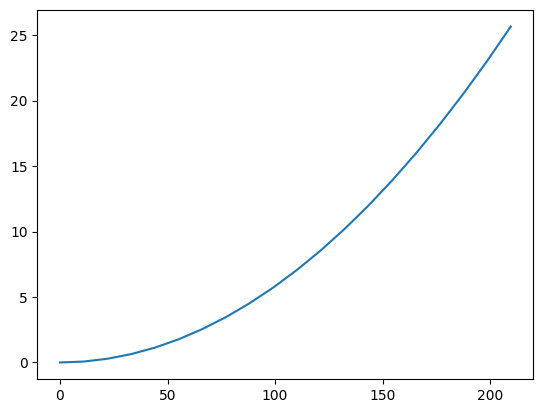

In [78]:
plt.plot(x0, z0)
plt.show()

In [79]:
q0=np.zeros(12*N)

In [80]:
for j in range(1,12):
    if j==1:
        q0[(j-1)*N:j*N]=x0
    elif j==5:
        q0[(j-1)*N:j*N]=z0

In [81]:
def static_func(Q): 
    t=0

    x,y,z=Q[0:N],Q[2*N:3*N],Q[4*N:5*N]
    dx,dy,dz=Q[1*N:2*N],Q[3*N:4*N],Q[5*N:6*N]
    φ,θ,ψ=Q[6*N:7*N],Q[8*N:9*N],Q[10*N:11*N]
    dφ,dθ,dψ=Q[7*N:8*N],Q[9*N:10*N],Q[11*N:12*N]
    
    RET = Ret(φ,θ,ψ)

    η = [x[-1],y[-1],z[-1],φ[-1],θ[-1],ψ[-1]]

    tau_force = np.array([-Fx_0,Fy_0,0,0,0,0])

    Z0 = tau_force[:3]    
    Z1 = d_s(ne, x, y, z, φ, θ, ψ).T
    Z2 = ne_hat(x, y, z, dx, dy, dz).T


    Z = (Z1 + Z2 - Z0)


############################################################
    ddx,ddy, ddz = (Z/mp).T
############################################################
    
    C0 = np.einsum('ijk,kp->ijp', Π(φ,θ,ψ), tau_force[3:].reshape(3,1))
    C1 = d_s(me, φ, θ, ψ, φ, θ, ψ)
    C = (C1.T - C0.squeeze())
 
    A0 = Jrho(RET,Jrho0)
    A_fin = np.einsum('ijk,ikr->ijr',A0, Π(φ,θ,ψ))

    B = np.einsum('ijk,ik->ij', dΠ(φ, θ, ψ, dφ, dθ, dψ), np.stack((dφ,dθ,dψ), axis=1))
    
    D = w_e(φ,θ,ψ,dφ,dθ,dψ)
    
    G = np.cross(d_s(phi,x,y,z,φ, θ, ψ).T, ne(x, y, z, φ, θ, ψ))
    L = np.einsum('ijk,ik->ij',RET, (DR@D.T).T) 
    
    H = np.cross(D,np.einsum('ijk,ik->ij', A0, D))

#############################################
    ddφ,ddθ,ddψ = np.linalg.solve(A_fin, C + G - L - H - np.einsum('ijk,ik->ij',A0, B)).T
#############################################

    ans=np.concatenate([dx, ddx, dy, ddy, dz, ddz, dφ, ddφ, dθ, ddθ, dψ, ddψ], axis=0)

    return ans

In [82]:
root_ = root(static_func, q0, method='df-sane')

In [83]:
root_

 message: too many function evaluations required
 success: False
     fun: [ 6.224e+01  6.224e+01 ...  0.000e+00  0.000e+00]
       x: [ 1.058e+03  1.069e+03 ...  0.000e+00  0.000e+00]
     nit: 330
    nfev: 1000
  method: df-sane

In [84]:
x0_, z0_=root_.x[:N],root_.x[4*N:5*N]

In [85]:
# q0 = root_.x                                            # start from static solution

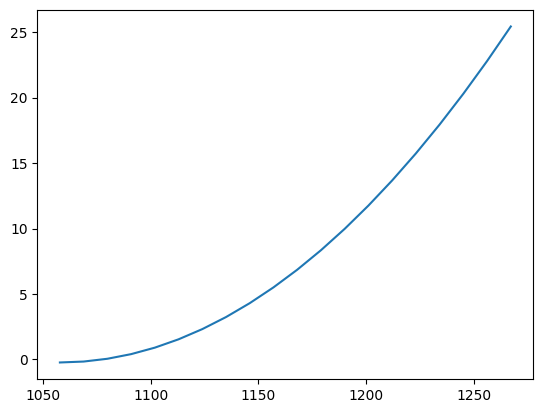

In [86]:
plt.plot(x0_, z0_)
plt.show()

### Vessle Simulation

In [87]:
sampleTime = 0.01              # sample time [seconds]
Number = 60000                      # number of samples

In [88]:
Number*sampleTime

600.0

In [89]:
vehicle=semisub('DPcontrol',1,-1,0.0,0,0)

In [90]:
[simTime, simData] = simulate(Number, sampleTime, vehicle)

In [91]:
simData.shape 

(60001, 24)

In [92]:
ans_t=[]
sum_=0
for i in range(simData.shape[0]):
    ans_t.append(sum_)
    sum_+=sampleTime

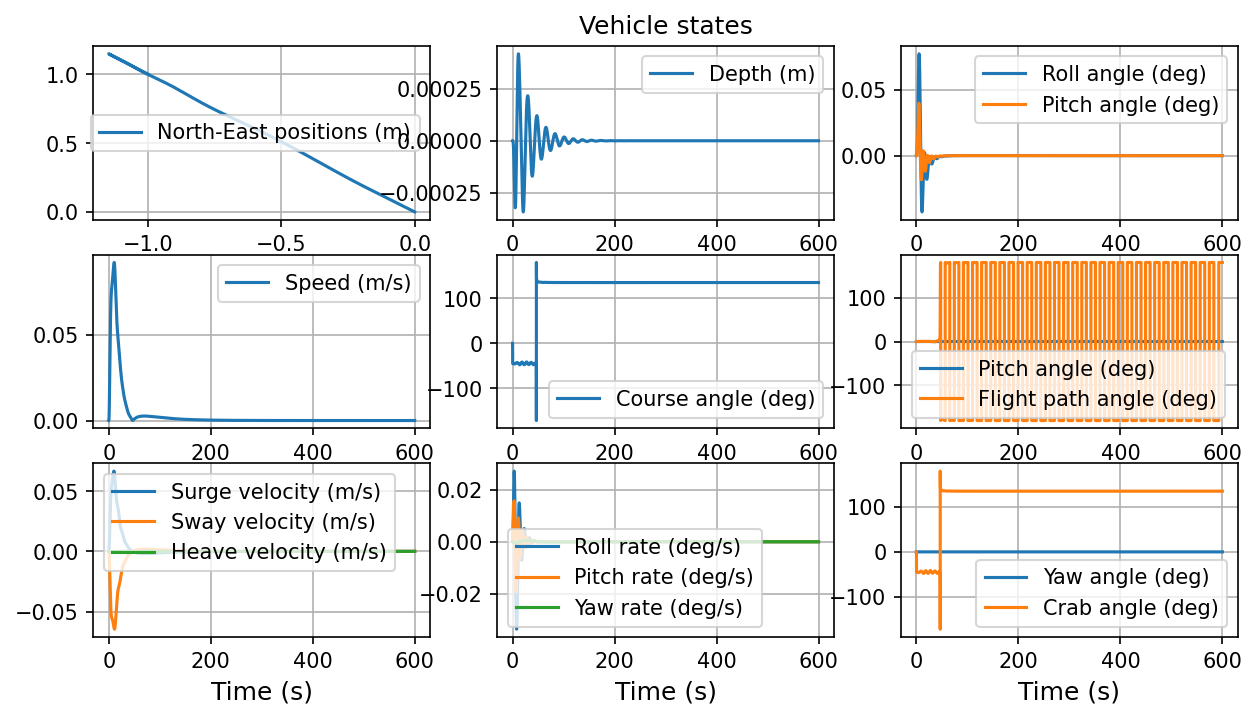

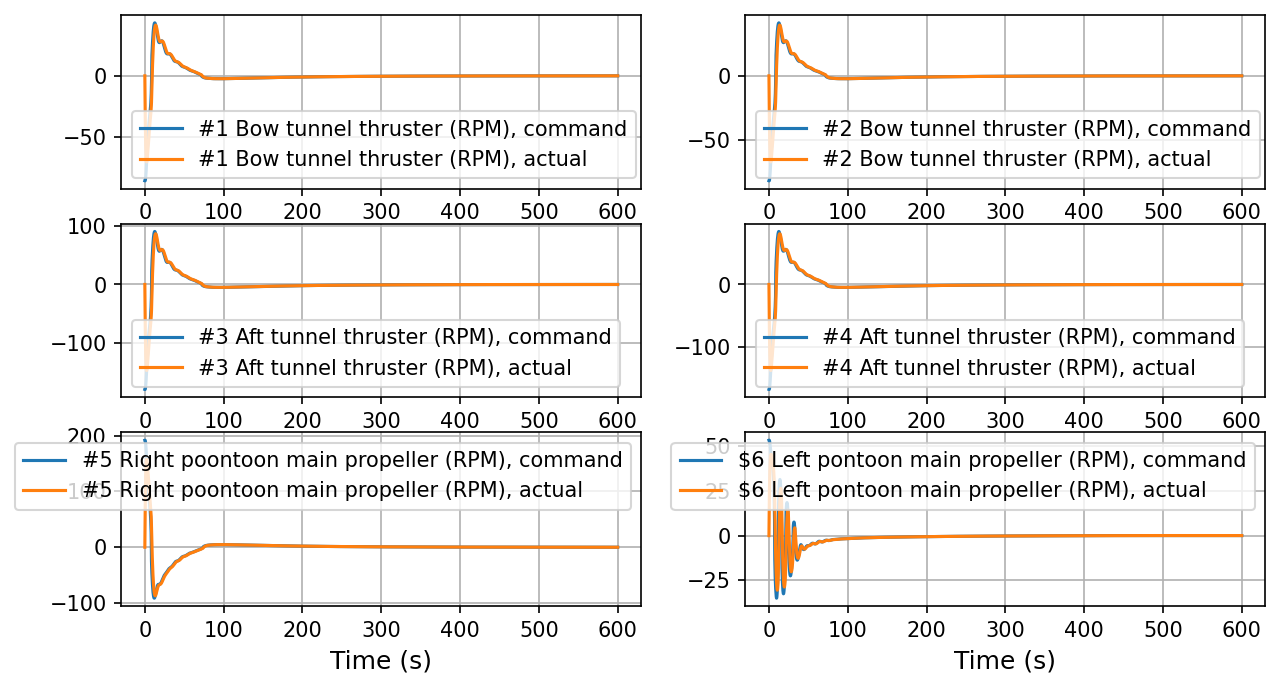

In [93]:
plotVehicleStates(simTime, simData, 1)
plotControls(simTime, simData, vehicle, 2)

In [94]:
numDataPoints = 5                 # number of 3D data points
FPS = 10                            # frames per second (animated GIF)
filename = '3D_animation.gif'       # data file for animated GIF
browser = 'safari'

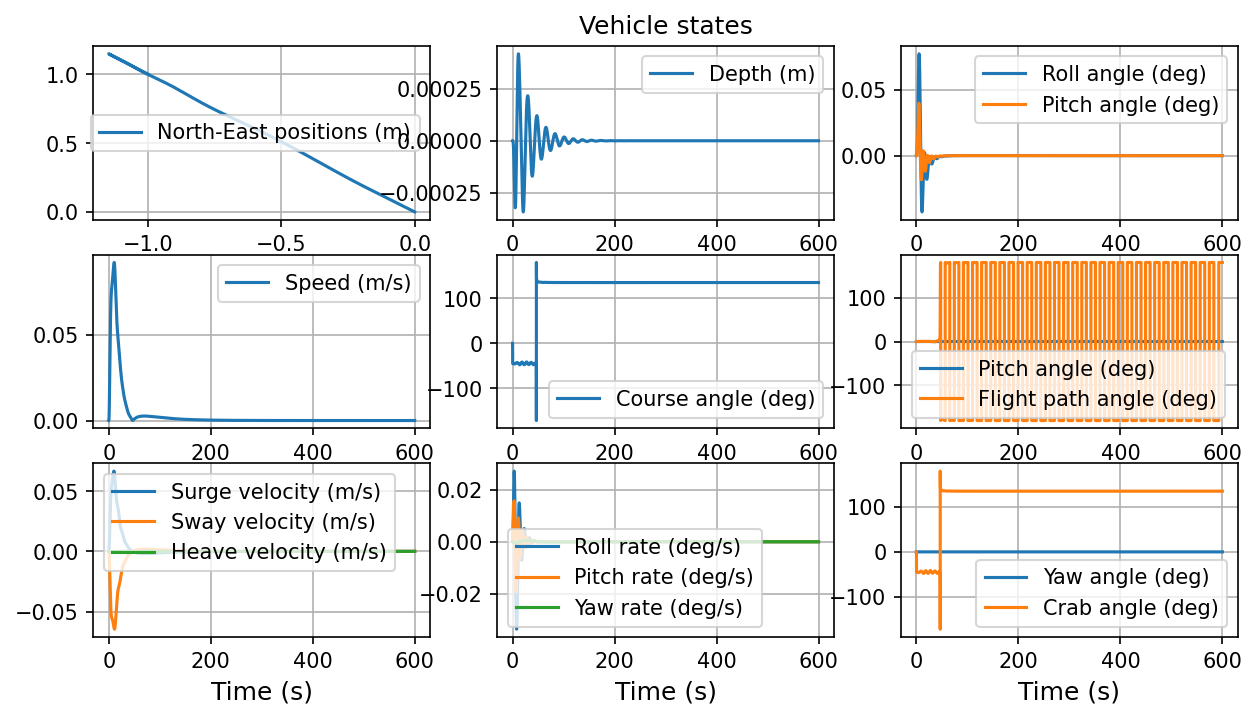

In [95]:
plotVehicleStates(simTime, simData, 3)

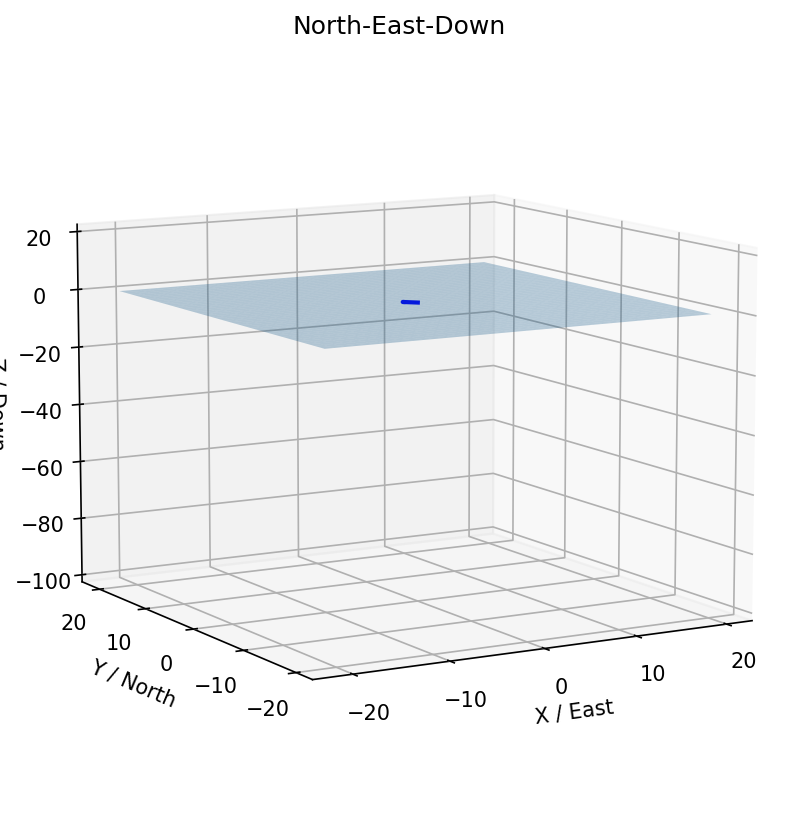

In [96]:
plot3D(simData, numDataPoints, FPS, filename, 3)

In [97]:
def find_nearest(array, value):
    array = np.asarray(array)
    idx = (np.abs(array - value)).argmin()
    return idx

In [98]:
class MyTime:
    def __init__(self):
        self.my_t = 0
        self.v_m = np.array([0,0,0,0,0,0]).astype(np.float64)
        self.progression = [i for i in range(650)]
        self.wall_clock = datetime.now()
        self.x_ve = 0
        self.y_ve = 0
        self.z_ve = 0
        self.phi_ve = 0
        self.theta_ve = 0
        self.psi_ve = 0
        self.top_tension = 0
        self.sagbend_strain = 0
        self.my_iter = 0

### Dynamics

In [99]:
def dynamic_func(t, Q, coefs, T, calibr):
    
    x,y,z=Q[0:N],Q[2*N:3*N],Q[4*N:5*N]
    dx,dy,dz=Q[1*N:2*N],Q[3*N:4*N],Q[5*N:6*N]
    φ,θ,ψ=Q[6*N:7*N],Q[8*N:9*N],Q[10*N:11*N]
    dφ,dθ,dψ=Q[7*N:8*N],Q[9*N:10*N],Q[11*N:12*N]
    
    idx = find_nearest(np.array(ans_t),  t)
    
    x_ve = simData[:, 0][idx]
    y_ve = simData[:, 1][idx]
    z_ve = simData[:, 2][idx]
    phi_ve = ssa(simData[:, 3][idx])
    theta_ve = ssa(simData[:, 4][idx])
    psi_ve = ssa(simData[:, 5][idx])
    

    
    RET = Ret(φ,θ,ψ)
    
    
    f0=simData[:, 12][idx]
    f1=simData[:, 13][idx]
    f2=simData[:, 14][idx]
    FF1=np.sqrt((f0)**2+(f1)**2+(f2)**2) 
    
    f3=simData[:, 15][idx]
    f4=simData[:, 16][idx]
    f5=simData[:, 17][idx]
    FF2=np.sqrt((f3)**2+(f4)**2+(f5)**2) 
    
#     position=np.sqrt((x)**2+(y)**2+(z)**2) 
#     velocity=np.sqrt((dx)**2+(dy)**2+(dz)**2)

    s = np.linspace(0, 1, N)

    x_ref = np.array(x0) + s * (x_ve - x0[-1])
    y_ref = np.zeros(N)  + s * y_ve
    z_ref = np.array(z0) + s * (z_ve - z0[-1])
    φ_ref = np.zeros(N)  + s * phi_ve
    θ_ref = np.zeros(N)  + s * theta_ve
    ψ_ref = np.zeros(N)  + s * psi_ve

    position  = np.sqrt((x - x_ref)**2 + (y - y_ref)**2 + (z - z_ref)**2)
    position1 = np.sqrt((φ - φ_ref)**2 + (θ - θ_ref)**2 + (ψ - ψ_ref)**2)

    velocity  = np.sqrt(dx**2 + dy**2 + dz**2)
    velocity1 = np.sqrt(dφ**2 + dθ**2 + dψ**2)     

#     position1=np.sqrt((φ)**2+(θ)**2+(ψ)**2)
#     velocity1=np.sqrt((dφ)**2+(dθ)**2+(dψ)**2)
    
    
    Z0 = calibr*FF1*(np.tile(position, (3, 1)) + np.tile(velocity, (3, 1))).T
    Z1 = d_s(ne, x, y, z, φ, θ, ψ).T
    Z2 = ne_hat(x, y, z, dx, dy, dz).T
    Z = (Z1 + Z2 - Z0 )

############################################################
    ddx,ddy, ddz = (Z/mp).T
############################################################
    
    C0 = calibr*FF2*(np.tile(position1, (3, 1)) + np.tile(velocity1, (3, 1))).T
    C1 = d_s(me, φ, θ, ψ, φ, θ, ψ).T
    C = (C1 - C0)

    A0 = Jrho(RET,Jrho0)
    A_fin = np.einsum('ijk,ikr->ijr', A0, Π(φ,θ,ψ))
    

    B = np.einsum('ijk,ik->ij', dΠ(φ, θ, ψ, dφ, dθ, dψ), np.stack((dφ,dθ,dψ), axis=1))
    
    D = w_e(φ,θ,ψ,dφ,dθ,dψ)
    
    G = np.cross(d_s(phi,x,y,z,φ, θ, ψ).T, ne(x, y, z, φ, θ, ψ))
    
    L = np.einsum('ijk,ik->ij',RET, (DR@D.T).T) 

    H = np.cross(D, np.einsum('ijk,ik->ij', A0, D))
    

#############################################
    ddφ,ddθ,ddψ = np.linalg.solve(A_fin, (C + G - L - H - np.einsum('ijk,ik->ij', A0, B))).T
#############################################


    if t>T.progression[0]:
        T.progression.pop(0)
        print('Physical time: ', t, ' Iteration wall-clock time: ', datetime.now() - T.wall_clock )
        T.wall_clock = datetime.now()   
         
    
    ans=np.concatenate([dx, ddx, 
                        dy, ddy, 
                        dz, ddz, 
                        dφ, ddφ, 
                        dθ, ddθ, 
                        dψ, ddψ
                       ], axis=0)
   
   
    if t>1:
        ax=np.einsum('ijk,ik->ij',np.linalg.inv(RET),ne(x, y, z, φ, θ, ψ))
        
        T.top_tension=max(T.top_tension, np.max(ax[-1,:]))
    
        ben=np.max(np.einsum('ijk,ik->ij',np.linalg.inv(RET), 
                         me(φ, θ, ψ, φ, θ, ψ)))/(mp*9.81*np.sqrt((x[-1]-x0_[-1])**2+
                                                                 (y[-1]-0)**2+(z[-1]-z0_[-1])**2)**2)

        I=3.14*(d0**4-dI**4)/64
        strain=np.max(ben)*d0/(2*E*I)    
        
        T.sagnend_strain=max(T.sagbend_strain, strain)
    T.my_iter+=1
    
    return ans

In [100]:
T_ = MyTime()

# initial conditions - to control dynamics
q0[6*N:7*N], q0[8*N:9*N], q0[10*N:11*N] = (np.array([0.01 for i in range(N)]),
                                          np.array([0.00003 for i in range(N)]),
                                          np.array([0.001267*i/N for i in range(N)]))

In [101]:
startTime1 = datetime.now()
us_ = solve_ivp(dynamic_func,
             tspan,
             q0,
             args=(coefs, T_, vessel_motion_calibration_coefficient,))
print(datetime.now() - startTime1)

Physical time:  9.304760674581673e-08  Iteration wall-clock time:  0:00:00.018150
Physical time:  1.0130218385638121  Iteration wall-clock time:  0:00:00.790985
Physical time:  2.006481163444373  Iteration wall-clock time:  0:00:01.022489
Physical time:  3.0039605451533196  Iteration wall-clock time:  0:00:00.884344
Physical time:  4.027396596935443  Iteration wall-clock time:  0:00:00.943587
Physical time:  5.00511954105631  Iteration wall-clock time:  0:00:00.970621
Physical time:  6.026748567609418  Iteration wall-clock time:  0:00:00.894120
Physical time:  7.004699142286298  Iteration wall-clock time:  0:00:00.948753
Physical time:  8.00408483087525  Iteration wall-clock time:  0:00:00.928205
Physical time:  9.002853013550633  Iteration wall-clock time:  0:00:00.927310
0:00:09.238329


In [102]:
# max axial tension
T_.top_tension

317963.6392141622

In [103]:
# max bending strain
T_.sagnend_strain*(mp*9.81*np.sqrt((x[-1]-x0_[-1])**2+(y[-1]-0)**2+(z[-1]-z0_[-1])**2)**2)

0.00012574898980780073

### Results

In [104]:
fin=us_

In [105]:
fin

  message: The solver successfully reached the end of the integration interval.
  success: True
   status: 0
        t: [ 0.000e+00  9.305e-06 ...  9.960e+00  1.000e+01]
        y: [[ 0.000e+00 -2.449e-21 ...  8.940e-03  9.057e-03]
            [ 1.103e+01  1.103e+01 ...  1.066e+01  1.066e+01]
            ...
            [ 0.000e+00 -1.230e-12 ... -6.640e-07 -6.660e-07]
            [ 0.000e+00 -1.231e-12 ... -6.629e-07 -6.648e-07]]
      sol: None
 t_events: None
 y_events: None
     nfev: 1622
     njev: 0
      nlu: 0

In [106]:
t=fin.t

In [107]:
fin=fin.y.T

In [108]:
t.shape, fin.shape

((213,), (213, 240))

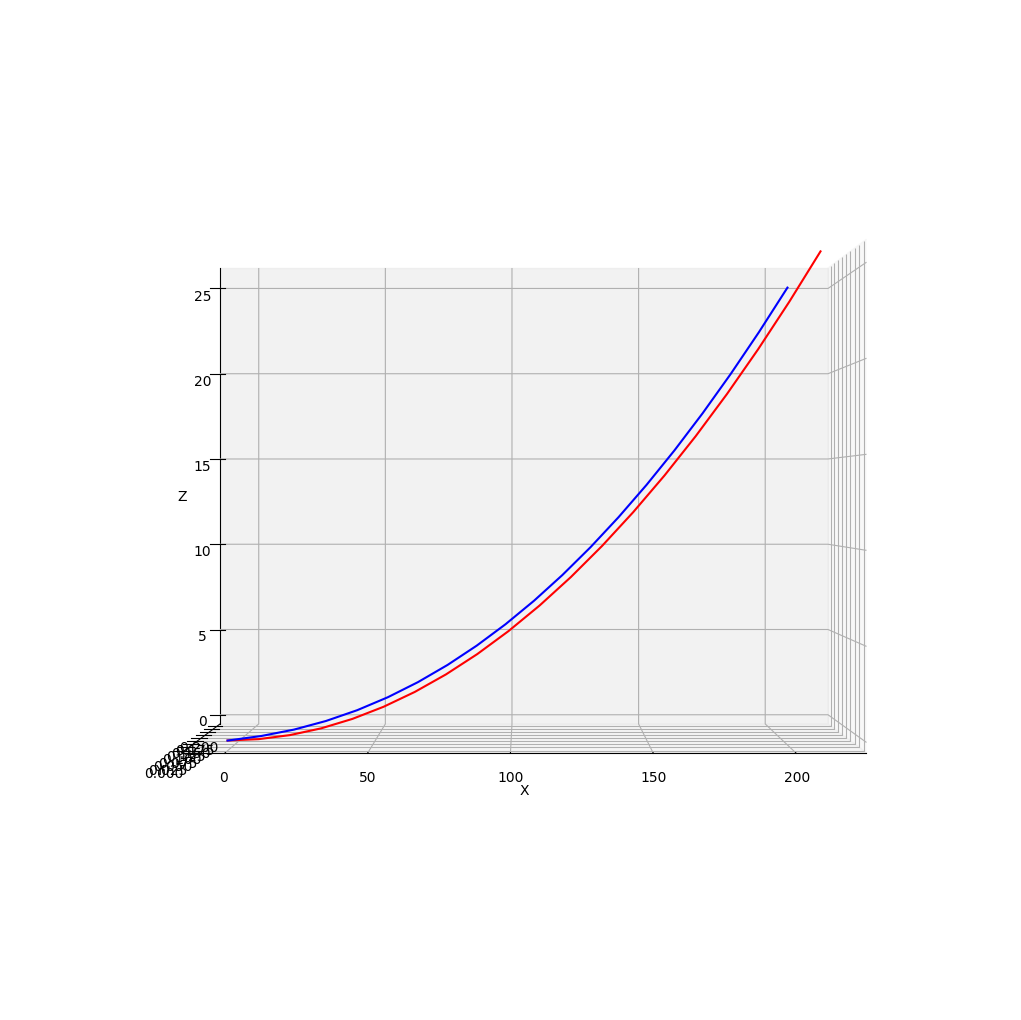

In [109]:
fig=plt.figure(figsize=(13,13))
ax = fig.add_subplot(projection = '3d')

X0=fin[0,[i for i in range(0,N)]]
Y0=fin[0,[i for i in range(2*N,3*N)]]
Z0=fin[0,[i for i in range(4*N,5*N)]]

j=-1
X=fin[j,[i for i in range(0,N)]]
Y=fin[j,[i for i in range(2*N,3*N)]]
Z=fin[j,[i for i in range(4*N,5*N)]]

num_true_pts = 200
tck, u = interpolate.splprep([X,Y,Z], s=2)
u_fine = np.linspace(0,1,num_true_pts)
x_fine, y_fine, z_fine = interpolate.splev(u_fine, tck)

ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
ax.plot(X0,Y0,Z0, color='r')
ax.plot(X,Y,Z, color='b')
ax.view_init(0,-90)
plt.show()

In [110]:
X,Y,Z

(array([9.05722895e-03, 1.06560891e+01, 2.14205120e+01, 3.22390690e+01,
        4.30908785e+01, 5.39668013e+01, 6.48623557e+01, 7.57754056e+01,
        8.67050870e+01, 9.76514243e+01, 1.08614916e+02, 1.19596218e+02,
        1.30595569e+02, 1.41612296e+02, 1.52644011e+02, 1.63687169e+02,
        1.74737928e+02, 1.85792691e+02, 1.96848542e+02, 2.07903480e+02]),
 array([1.93118943e-05, 2.59165297e-02, 4.71556607e-02, 6.69945220e-02,
        8.54991994e-02, 1.02669084e-01, 1.18496247e-01, 1.32972152e-01,
        1.46088676e-01, 1.57838631e-01, 1.68215913e-01, 1.77215755e-01,
        1.84834687e-01, 1.91070592e-01, 1.95922248e-01, 1.99390688e-01,
        2.01480685e-01, 2.02200930e-01, 2.01563139e-01, 1.99574458e-01]),
 array([-4.41964773e-03,  5.93314921e-02,  2.58375898e-01,  5.94840466e-01,
         1.06930194e+00,  1.68212256e+00,  2.43359900e+00,  3.32401560e+00,
         4.35366680e+00,  5.52287655e+00,  6.83200062e+00,  8.28141966e+00,
         9.87150022e+00,  1.16025404e+01,  1.347

In [111]:
X0,Y0,Z0

(array([  0.        ,  11.02712714,  22.05425428,  33.08138141,
         44.10850855,  55.13563569,  66.16276283,  77.18988997,
         88.21701711,  99.24414424, 110.27127138, 121.29839852,
        132.32552566, 143.3526528 , 154.37977994, 165.40690707,
        176.43403421, 187.46116135, 198.48828849, 209.51541563]),
 array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0.]),
 array([ 0.        ,  0.07074654,  0.28299779,  0.63678871,  1.13217754,
         1.76924585,  2.54809852,  3.46886379,  4.53169324,  5.73676187,
         7.08426809,  8.57443374, 10.20750417, 11.98374825, 13.90345843,
        15.96695076, 18.17456499, 20.52666459, 23.02363679, 25.66589272]))

In [112]:
us=fin.T

In [113]:
us.shape

(240, 213)

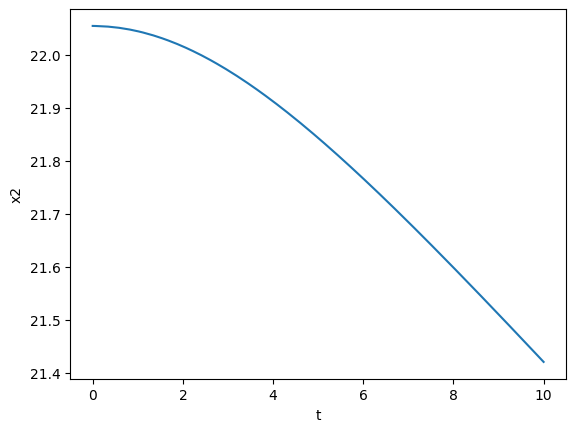

In [114]:
plt.plot(t,us.T[:,2],'-')
plt.xlabel('t')
plt.ylabel('x2')
plt.show()

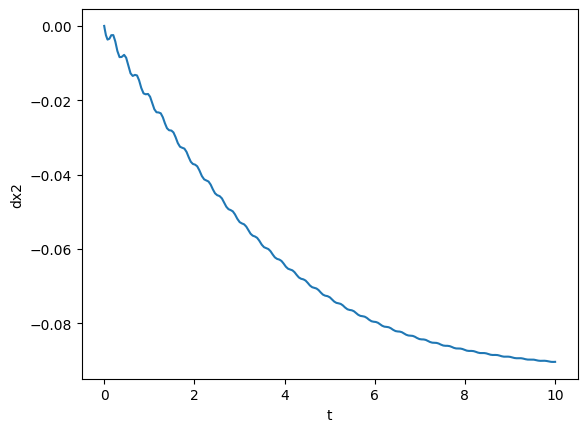

In [115]:
plt.plot(t,us.T[:,N+2] ,'-')
plt.xlabel('t')
plt.ylabel('dx2')
plt.show()

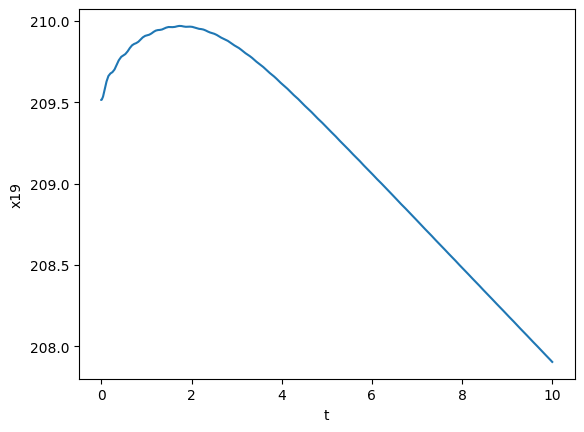

In [116]:
plt.plot(t,us.T[:,N-1] ,'-')
plt.xlabel('t')
plt.ylabel('x{}'.format(N-1))
plt.show()

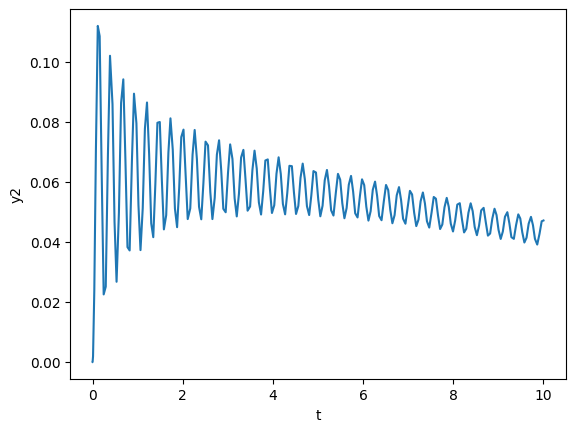

In [117]:
plt.plot(t,us.T[:,2*N +2] ,'-')
plt.xlabel('t')
plt.ylabel('y2')
plt.show()

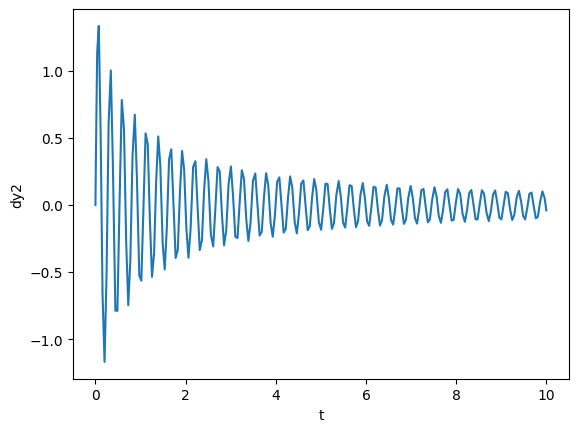

In [118]:
plt.plot(t,us.T[:,3*N+2] ,'-')
plt.xlabel('t')
plt.ylabel('dy2')
plt.show()

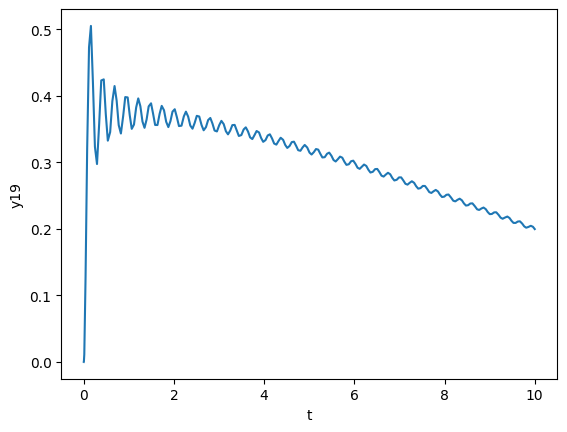

In [119]:
plt.plot(t,us.T[:,2*N+(N-1)] ,'-')
plt.xlabel('t')
plt.ylabel('y{}'.format(N-1))
plt.show()

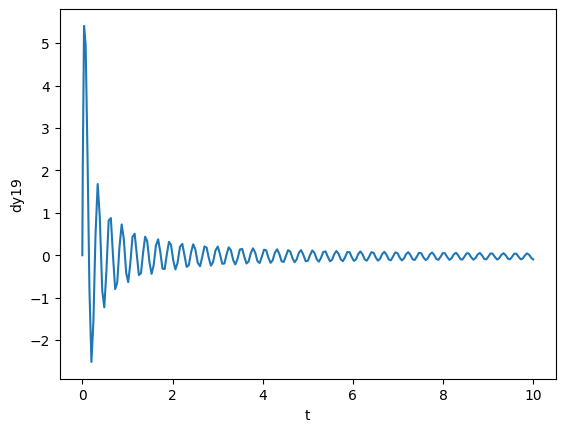

In [120]:
plt.plot(t,us.T[:,3*N+(N-1)] ,'-')
plt.xlabel('t')
plt.ylabel('dy{}'.format(N-1))
plt.show()

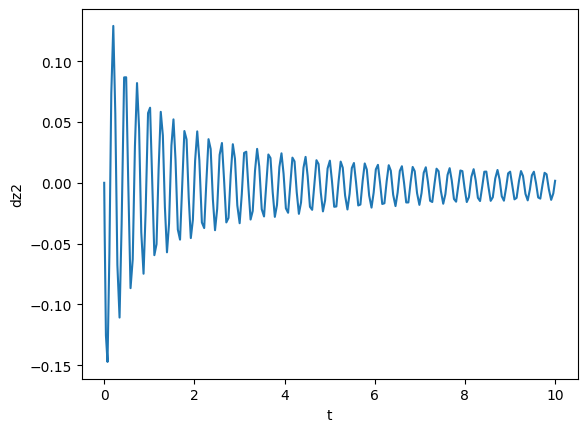

In [121]:
plt.plot(t,us.T[:,5*N+2] ,'-')
plt.xlabel('t')
plt.ylabel('dz2')
plt.show()

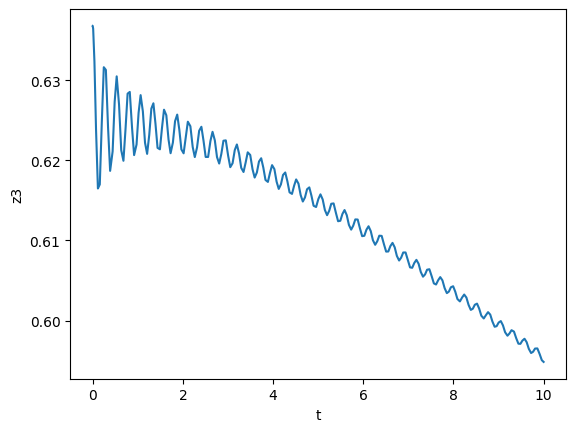

In [122]:
plt.plot(t,us.T[:,4*N+3] ,'-')
plt.xlabel('t')
plt.ylabel('z3')
plt.show()

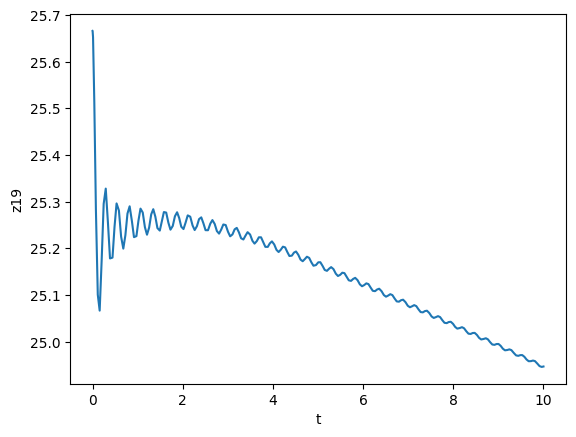

In [123]:
plt.plot(t,us.T[:,4*N + (N-1)] ,'-')
plt.xlabel('t')
plt.ylabel('z{}'.format(N-1))
plt.show()

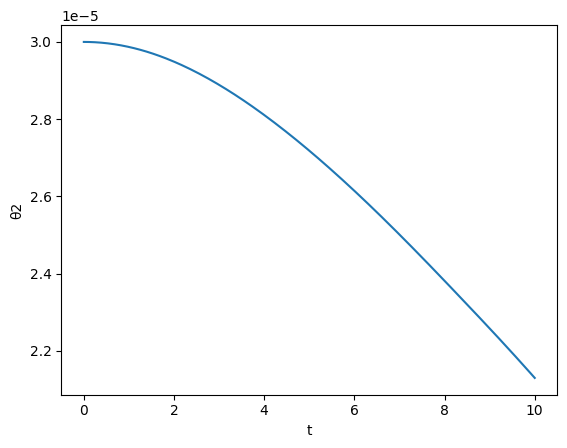

In [124]:
plt.plot(t,us.T[:,8*N+2],'-')
plt.xlabel('t')
plt.ylabel('θ2')
plt.show()

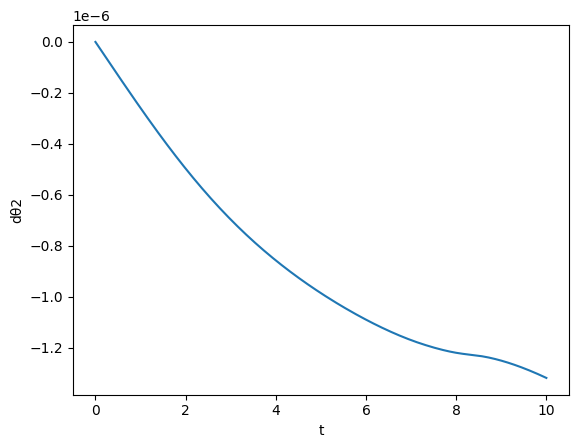

In [125]:
plt.plot(t,us.T[:,9*N+2] ,'-')
plt.xlabel('t')
plt.ylabel('dθ2')
plt.show()

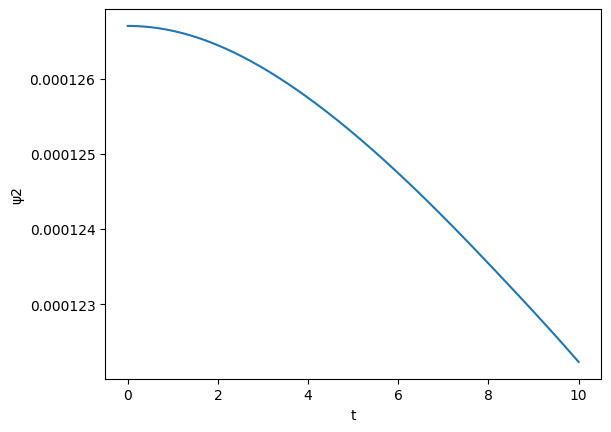

In [126]:
plt.plot(t,us.T[:,10*N+2],'-')
plt.xlabel('t')
plt.ylabel('ψ2')
plt.show()

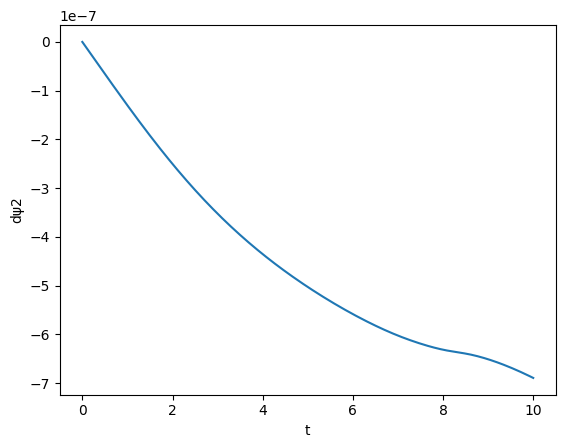

In [127]:
plt.plot(t,us.T[:,11*N+2] ,'-')
plt.xlabel('t')
plt.ylabel('dψ2')
plt.show()

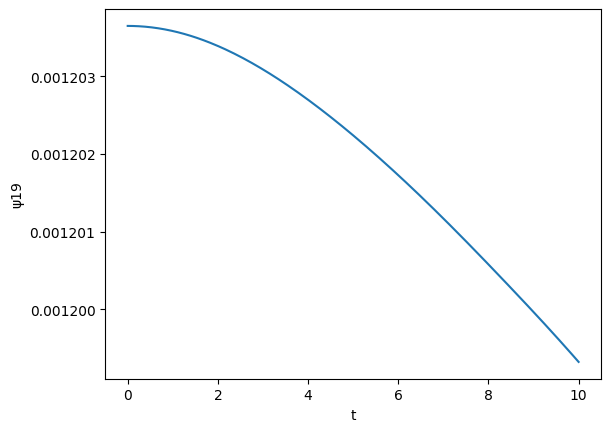

In [128]:
plt.plot(t,us.T[:,10*N + (N-1)] ,'-')
plt.xlabel('t')
plt.ylabel('ψ{}'.format(N-1))
plt.show()

In [129]:
X010=us.T[:,0*N:1*N]

In [130]:
Y010=us.T[:,2*N:3*N]

In [131]:
Z010=us.T[:,4*N:5*N]

In [132]:
# simulation = np.stack([X010,Y010,Z010],axis=2) 

# FPS = 30                      
# frame_duration = 1000 / FPS

# frames = []
# for t in range(simulation.shape[0]):
#     x = simulation[t,:,0]
#     y = simulation[t,:,1]
#     z = simulation[t,:,2]

#     frames.append(go.Frame(
#         data=[
#             go.Scatter3d(
#                 x=x, y=y, z=z,
#                 mode="lines+markers",
#                 marker=dict(size=5, color=list(range(12)), colorscale="Viridis"),
#                 line=dict(width=4)
#             )
#         ],
#         name=f"t={t}"
#     ))

# # First frame
# x0, y0, z0 = simulation[0,:,0], simulation[0,:,1], simulation[0,:,2]

# fig = go.Figure(
#     data=[go.Scatter3d(x=x0, y=y0, z=z0, mode="lines+markers")],
#     frames=frames
# )

# # Animation controls
# fig.update_layout(
#     title="Pipeline Simulation ",
#     scene=dict(
#         xaxis_title="X",
#         yaxis_title="Y",
#         zaxis_title="Z",
#         xaxis=dict(range=[0, 300]),
#         yaxis=dict(range=[-50, 50]),
#         zaxis=dict(range=[0, 40]),
#         aspectmode="data",
       
#     ),
#     updatemenus=[{
#         "type": "buttons",
#         "buttons": [
#             {
#                 "label": "Play",
#                 "method": "animate",
#                 "args": [None, {"frame": {"duration": frame_duration, "redraw": True}}]
#             },
#             {
#                 "label": "Pause",
#                 "method": "animate",
#                 "args": [[None], {"frame": {"duration": 0}}]
#             }
#         ]
#     }]
# )

# fig.show()